# Non-Reversible Parallel Tempering in THRML-Boost

This notebook demonstrates the parallel tempering features in `thrml_boost.nrpt`, based on [Syed et al. (2021)](https://arxiv.org/abs/1905.02939). We cover:

1. **Basic NRPT** — DEO swap scheme with vectorized temperature-linear swaps
2. **Round trip tracking** — monitoring the index process and counting round trips
3. **Communication barrier** — estimating Λ and the local barrier λ(β)
4. **Adaptive schedule optimization** — iteratively tuning β to equalize rejection rates
5. **Influence-aware blocking** — adapting block structure to coupling strength
6. **Boundary energy analysis** — quantifying FLOPS savings from rectangular blocks

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from thrml_boost import Block, SpinNode
from thrml_boost.models import IsingEBM, IsingSamplingProgram, hinton_init
from thrml_boost.nrpt import nrpt, nrpt_adaptive, discover_chain_count
from thrml_boost.round_trips import predict_optimal_round_trip_rate, recommend_n_chains
from thrml_boost.dynamic_blocks import (
    compute_aggregate_influence,
    classify_nodes,
    per_temperature_block_config,
)
from thrml_boost.boundary_energy import (
    EdgePartition,
    make_rectangular_blocks,
    estimate_boundary_savings,
)

## Helper: build an L×L Ising grid

In [2]:
def make_ising_grid(L, coupling=1.0, field=0.0):
    """L×L nearest-neighbor Ising model with checkerboard blocking."""
    nodes_2d = [[SpinNode() for _ in range(L)] for _ in range(L)]
    nodes = [n for row in nodes_2d for n in row]
    edges = []
    for i in range(L):
        for j in range(L):
            if j + 1 < L:
                edges.append((nodes_2d[i][j], nodes_2d[i][j + 1]))
            if i + 1 < L:
                edges.append((nodes_2d[i][j], nodes_2d[i + 1][j]))
    biases = jnp.ones(len(nodes)) * field
    weights = jnp.ones(len(edges)) * coupling
    even = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 0]
    odd = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 1]
    free_blocks = [Block(even), Block(odd)]
    return nodes, nodes_2d, edges, biases, weights, free_blocks

## 1. Basic NRPT

The core `nrpt()` function runs non-reversible parallel tempering: deterministic even-odd (DEO) swap alternation with vectorized swap acceptance via temperature linearity. One energy evaluation per chain replaces four per pair.

In [3]:
L = 16
nodes, nodes_2d, edges, biases, weights, free_blocks = make_ising_grid(L, coupling=1.0)

n_chains = 8
betas = jnp.linspace(0.2, 1.0, n_chains)

ebms = [IsingEBM(nodes, edges, biases, weights, jnp.array(float(b))) for b in betas]
programs = [IsingSamplingProgram(e, free_blocks, []) for e in ebms]

key = jax.random.key(42)
keys = jax.random.split(key, n_chains + 1)
init_states = [hinton_init(keys[i], ebms[0], free_blocks, ()) for i in range(n_chains)]

states, ss, stats = nrpt(
    keys[-1],
    ebms,
    programs,
    init_states,
    [],
    n_rounds=300,
    gibbs_steps_per_round=5,
)

print(f"Chains: {n_chains}")
print(f"Betas:  {[f'{b:.3f}' for b in betas]}")
print(f"Acceptance rates: {[f'{float(r):.3f}' for r in stats['acceptance_rate']]}")
print(f"Rejection rates:  {[f'{float(r):.3f}' for r in stats['rejection_rates']]}")

Chains: 8
Betas:  ['0.200', '0.314', '0.429', '0.543', '0.657', '0.771', '0.886', '1.000']
Acceptance rates: ['0.060', '0.007', '0.000', '0.120', '0.320', '0.507', '0.773']
Rejection rates:  ['0.940', '0.993', '1.000', '0.880', '0.680', '0.493', '0.227']


## 2. Round trip tracking

With `track_round_trips=True` (the default), `nrpt` monitors the index process: which chain slot each machine's state occupies, how many times it has completed a full round trip (reference → target → reference), and the total number of restarts (reaching the target chain).

This directly measures the information transfer between the reference and target distributions — the quantity that determines PT effectiveness.

In [4]:
diag = stats["round_trip_diagnostics"]

print("Round trip diagnostics")
print(f"  Global barrier Λ:       {float(diag['Lambda']):.4f}")
print(f"  Predicted \u03c4\u0304 = 1/(2+2\u039b): {float(diag['tau_predicted']):.4f}")
print(f"  Observed \u03c4:             {float(diag['tau_observed']):.4f}")
print(f"  Efficiency (\u03c4_obs/\u03c4\u0304):   {float(diag['efficiency']):.4f}")
print()
print(f"  Round trips per machine: {diag['round_trips_per_chain'].tolist()}")
print(f"  Restarts per machine:    {diag['restarts_per_chain'].tolist()}")

Round trip diagnostics
  Global barrier Λ:       5.2133
  Predicted τ̄ = 1/(2+2Λ): 0.0805
  Observed τ:             0.0000
  Efficiency (τ_obs/τ̄):   0.0000

  Round trips per machine: [0, 0, 0, 0, 0, 0, 0, 0]
  Restarts per machine:    [0, 0, 0, 1, 1, 1, 1, 1]


In [5]:
idx = stats["index_state"]
print(f"Machine-to-chain mapping: {idx['machine_to_chain'].tolist()}")
print(f"Visited top (chain N):    {idx['visited_top'].tolist()}")

Machine-to-chain mapping: [2, 0, 1, 3, 5, 7, 6, 4]
Visited top (chain N):    [False, False, False, True, True, True, True, True]


## 3. Communication barrier λ(β)

The local communication barrier λ(β) = r(i,i+1) / Δβ measures how hard it is to communicate at each temperature. Peaks in λ(β) indicate where the schedule needs more chains. For the 2D Ising model, this peaks near the critical temperature β_c ≈ 0.44.

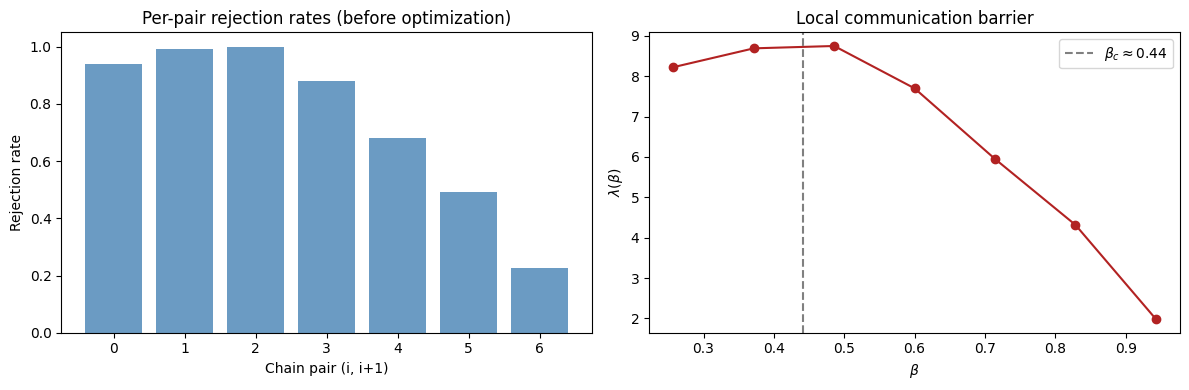

In [6]:
lambda_profile = diag["lambda_profile"]
beta_midpoints = (betas[:-1] + betas[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    range(len(stats["rejection_rates"])),
    np.array(stats["rejection_rates"]),
    color="steelblue",
    alpha=0.8,
)
axes[0].set_xlabel("Chain pair (i, i+1)")
axes[0].set_ylabel("Rejection rate")
axes[0].set_title("Per-pair rejection rates (before optimization)")

axes[1].plot(
    np.array(beta_midpoints), np.array(lambda_profile), "o-", color="firebrick"
)
axes[1].axvline(0.4407, color="gray", ls="--", label="$\\beta_c \\approx 0.44$")
axes[1].set_xlabel("$\\beta$")
axes[1].set_ylabel("$\\lambda(\\beta)$")
axes[1].set_title("Local communication barrier")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Adaptive schedule optimization

The uniform β spacing above produces uneven rejection rates — high near the critical region, low elsewhere. `nrpt_adaptive` implements Algorithm 4 from Syed et al.: iteratively adjust the schedule so that rejection rates are equalized across all pairs. This minimizes the schedule inefficiency E(P_N) and approaches the theoretical bound τ̄ = 1/(2+2Λ).

In [7]:
def ebm_factory(bs):
    return [IsingEBM(nodes, edges, biases, weights, jnp.array(float(b))) for b in bs]


def program_factory(ebm_list):
    return [IsingSamplingProgram(e, free_blocks, []) for e in ebm_list]


key_adapt = jax.random.key(42)
initial_betas = jnp.linspace(0.2, 1.0, n_chains)

states_adapt, _, stats_adapt = nrpt_adaptive(
    key_adapt,
    ebm_factory,
    program_factory,
    init_states,
    [],
    n_rounds=300,
    gibbs_steps_per_round=5,
    initial_betas=initial_betas,
    n_tune=8,
    rounds_per_tune=100,
)

In [8]:
print("Schedule optimization results")
print(f"  Initial betas: {[f'{b:.3f}' for b in initial_betas]}")
print(f"  Final betas:   {[f'{float(b):.3f}' for b in stats_adapt['betas']]}")
print(
    f"  Final rejection rates: {[f'{float(r):.3f}' for r in stats_adapt['rejection_rates']]}"
)
print()
diag_adapt = stats_adapt["round_trip_diagnostics"]
print(f"  \u039b (after opt):  {float(diag_adapt['Lambda']):.4f}")
print(f"  \u03c4\u0304 predicted:    {float(diag_adapt['tau_predicted']):.4f}")
print(f"  \u03c4 observed:     {float(diag_adapt['tau_observed']):.4f}")
print(f"  Round trips:    {diag_adapt['round_trips_per_chain'].tolist()}")

Schedule optimization results
  Initial betas: ['0.200', '0.314', '0.429', '0.543', '0.657', '0.771', '0.886', '1.000']
  Final betas:   ['0.200', '0.280', '0.356', '0.434', '0.494', '0.561', '0.694', '1.000']
  Final rejection rates: ['0.867', '0.820', '0.893', '0.880', '0.807', '0.893', '0.873']

  Λ (after opt):  6.0333
  τ̄ predicted:    0.0711
  τ observed:     0.0033
  Round trips:    [0, 0, 0, 0, 0, 0, 0, 1]


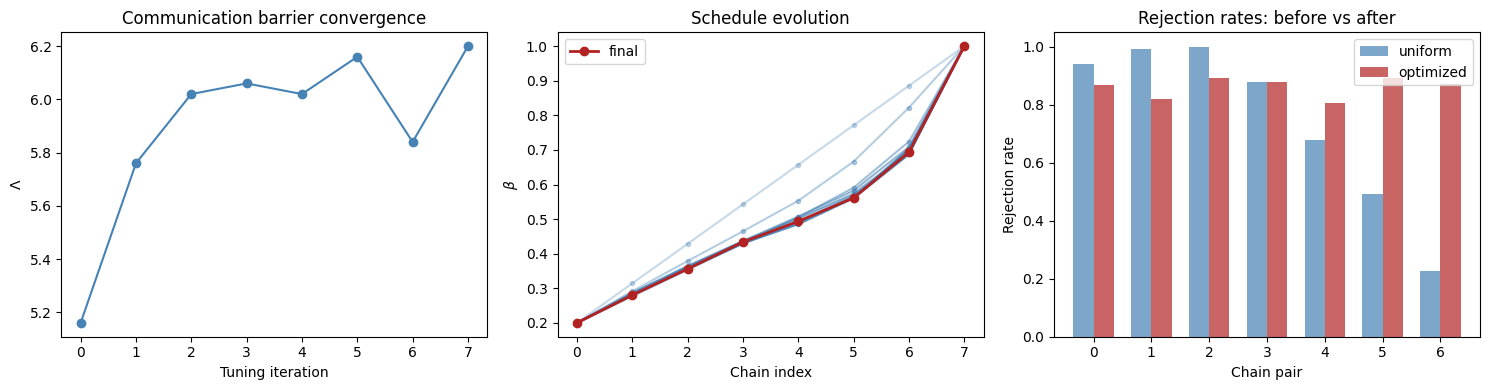

In [9]:
history = stats_adapt["tuning_history"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lambdas = [h["Lambda"] for h in history]
axes[0].plot(range(len(lambdas)), lambdas, "o-", color="steelblue")
axes[0].set_xlabel("Tuning iteration")
axes[0].set_ylabel("$\\Lambda$")
axes[0].set_title("Communication barrier convergence")

for i, h in enumerate(history):
    alpha = 0.3 + 0.7 * (i / max(len(history) - 1, 1))
    axes[1].plot(
        range(n_chains),
        np.array(h["betas"]),
        "o-",
        alpha=alpha,
        color="steelblue",
        markersize=3,
    )
axes[1].plot(
    range(n_chains),
    np.array(stats_adapt["betas"]),
    "o-",
    color="firebrick",
    label="final",
    linewidth=2,
)
axes[1].set_xlabel("Chain index")
axes[1].set_ylabel("$\\beta$")
axes[1].set_title("Schedule evolution")
axes[1].legend()

x = np.arange(n_chains - 1)
w = 0.35
axes[2].bar(
    x - w / 2,
    np.array(stats["rejection_rates"]),
    w,
    label="uniform",
    color="steelblue",
    alpha=0.7,
)
axes[2].bar(
    x + w / 2,
    np.array(stats_adapt["rejection_rates"]),
    w,
    label="optimized",
    color="firebrick",
    alpha=0.7,
)
axes[2].set_xlabel("Chain pair")
axes[2].set_ylabel("Rejection rate")
axes[2].set_title("Rejection rates: before vs after")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Recommended chain count

Given an estimated Λ, `recommend_n_chains` computes N = Λ / (1 - target_acceptance). The default is 60% acceptance (40% rejection per pair).

**Important caveat**: Λ estimated from too few chains is biased low. The schedule can't resolve the peak in λ(β) when chains are sparse, so the measured Λ underestimates the true barrier. This makes `recommend_n_chains` underestimate N, which leads to high rejection rates, which leads to re-running with more chains and getting a higher Λ. Section 9 shows how to handle this automatically.

In [10]:
Lambda = float(diag_adapt["Lambda"])
print(f"Estimated \u039b = {Lambda:.3f}")
print()
for acc in [0.7, 0.6, 0.5, 0.4]:
    n_rec = recommend_n_chains(Lambda, target_acceptance=acc)
    r_star = 1 - acc
    print(f"  target acceptance = {acc:.0%}  (r* = {r_star:.0%})  \u2192  N = {n_rec}")
print()
print(f"Predicted \u03c4\u0304 = {float(predict_optimal_round_trip_rate(Lambda)):.4f}")
print("(\u03c4\u0304 depends only on \u039b, not on N or the schedule)")

Estimated Λ = 6.033

  target acceptance = 70%  (r* = 30%)  →  N = 20
  target acceptance = 60%  (r* = 40%)  →  N = 15
  target acceptance = 50%  (r* = 50%)  →  N = 12
  target acceptance = 40%  (r* = 60%)  →  N = 10

Predicted τ̄ = 0.0711
(τ̄ depends only on Λ, not on N or the schedule)


## 6. Influence-aware blocking

The aggregate influence $A(w) = \sum_{z \sim w} \Gamma_{w,z}$ measures how strongly each node is coupled to its neighbors at a given $\beta$. On a **uniform-coupling grid**, this reduces to $A(w) = \text{degree}(w) \times \Gamma(\beta)$ and is uninformative — it just shows you the grid's degree structure.

The metric becomes useful with **heterogeneous couplings** (spin glasses, learned EBMs). We demonstrate with a random-coupling Ising model where $J_{ij} \sim \mathcal{N}(0, 1)$.

The actionable output isn't the raw values — it's the binary classification into **heavy** nodes (should be interior to blocks) and **light** nodes (safe on boundaries). This feeds directly into `influence_aware_partition`.

In [11]:
# Block size recommendations: peaks at β_c because correlation length diverges
test_betas = [0.1, 0.2, 0.44, 0.6, 1.0, 2.0]
recommended = per_temperature_block_config(test_betas, beta_c=0.4407, max_size=16)

for b, s in zip(test_betas, recommended):
    print(f"  \u03b2 = {b:.2f}  \u2192  block size = {s}")

print()
print(
    "At \u03b2_c the correlation length \u03be diverges (\u03be ~ L for finite grids),"
)
print("so the recommendation saturates at max_size. This is the fundamental")
print("limitation of block Gibbs at criticality \u2014 cluster algorithms bypass it.")

  β = 0.10  →  block size = 5
  β = 0.20  →  block size = 8
  β = 0.44  →  block size = 16
  β = 0.60  →  block size = 12
  β = 1.00  →  block size = 3
  β = 2.00  →  block size = 1

At β_c the correlation length ξ diverges (ξ ~ L for finite grids),
so the recommendation saturates at max_size. This is the fundamental
limitation of block Gibbs at criticality — cluster algorithms bypass it.


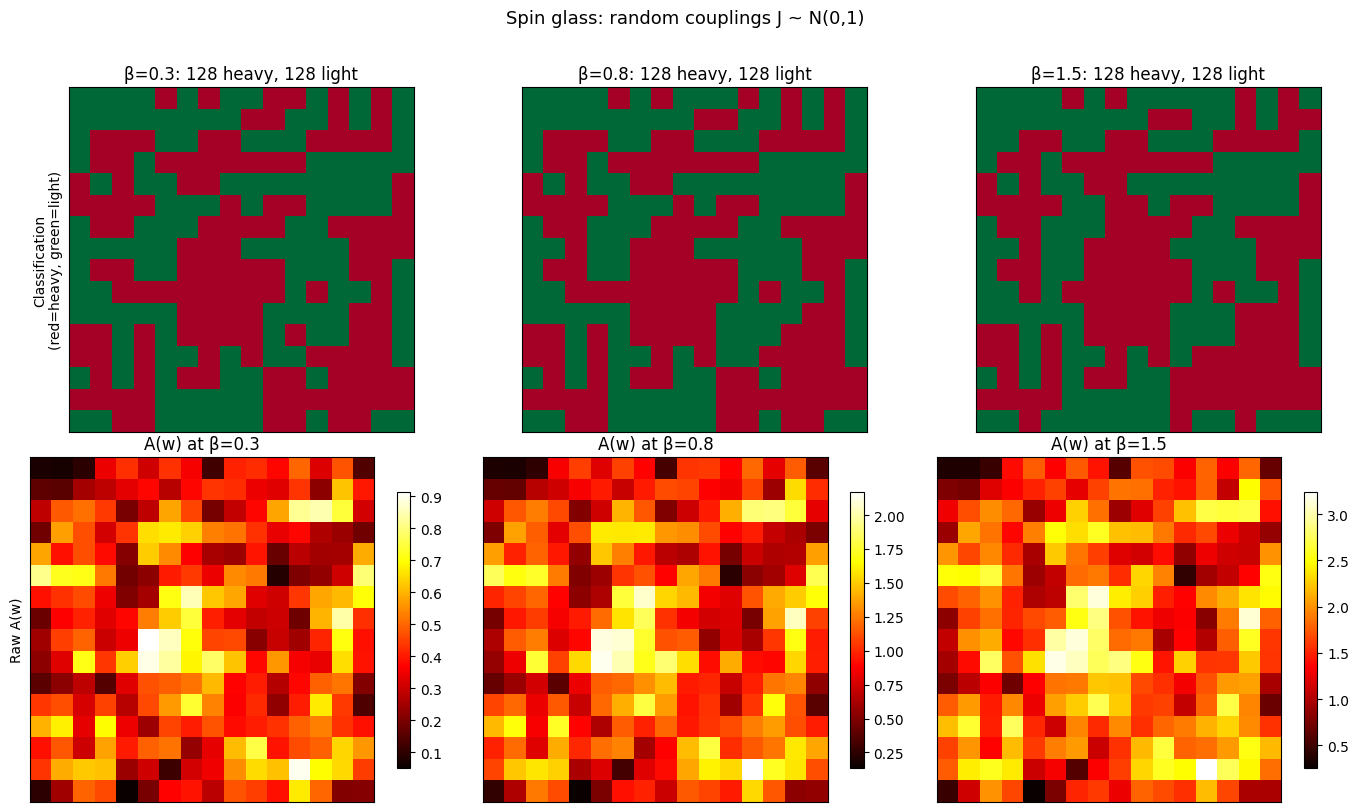

In [24]:
# Spin glass: random couplings reveal the actual utility of aggregate influence
key_w = jax.random.key(42)
random_weights = jax.random.normal(key_w, (len(edges),))
w_np = np.array(random_weights)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

beta_vals = [0.3, 0.8, 1.5]

# Top row: binary classification (the actionable output)
for ax, beta_val in zip(axes[0], beta_vals):
    agg, _ = compute_aggregate_influence(edges, w_np, beta_val, nodes)
    heavy, light = classify_nodes(agg)
    grid = np.full(L * L, 0.5)  # neutral
    grid[heavy] = 1.0
    grid[light] = 0.0
    ax.imshow(grid.reshape(L, L), cmap="RdYlGn_r", vmin=0, vmax=1)
    ax.set_title(f"\u03b2={beta_val}: {len(heavy)} heavy, {len(light)} light")
    ax.set_xticks([])
    ax.set_yticks([])

# Bottom row: raw aggregate influence for reference
for ax, beta_val in zip(axes[1], beta_vals):
    agg, _ = compute_aggregate_influence(edges, w_np, beta_val, nodes)
    im = ax.imshow(agg.reshape(L, L), cmap="hot", interpolation="nearest")
    ax.set_title(f"A(w) at \u03b2={beta_val}")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)

axes[0][0].set_ylabel("Classification\n(red=heavy, green=light)", fontsize=10)
axes[1][0].set_ylabel("Raw A(w)", fontsize=10)

plt.suptitle("Spin glass: random couplings J ~ N(0,1)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Top row**: the actionable output. Red nodes are "heavy" (aggregate influence above median) and should be placed interior to blocks where their strong couplings don't cross block boundaries. Green nodes are "light" and safe on boundaries. At low β, few nodes are heavy. At high β, the classification is more extreme — the hottest nodes demand large blocks.

**Bottom row**: the raw A(w) values that the classification thresholds. With random couplings, you can see genuine spatial variation — unlike the uniform grid where every interior node has the same value.

For uniform-coupling grids (like the model in Sections 1–4), aggregate influence is uninformative and you should stick with standard checkerboard blocking. The metric earns its keep on spin glasses, portfolio optimization Ising models, and learned EBMs where $J_{ij}$ varies across edges.

## 7. Boundary energy analysis

THRML currently uses checkerboard (2-coloring) blocks where every edge crosses the block boundary. Moving to m×m rectangular blocks (4-coloring) introduces interior edges, and the boundary/incident ratio drops as O(1/m).

`EdgePartition` classifies edges, and `estimate_boundary_savings` quantifies the expected FLOPS reduction.

In [13]:
even_nodes = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 0]
odd_nodes = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 1]
ep_checker = EdgePartition(edges, [even_nodes, odd_nodes])

print("Checkerboard (2-coloring):")
print(f"  Total edges: {len(edges)}")
print(
    f"  Block 0: {ep_checker.n_boundary[0]} boundary, {ep_checker.n_interior[0]} interior"
)
print(f"  Boundary ratio: {ep_checker.boundary_ratio[0]:.2f}")

Checkerboard (2-coloring):
  Total edges: 480
  Block 0: 480 boundary, 0 interior
  Boundary ratio: 1.00


In [14]:
print(
    f"{'block_size':>10} {'n_blocks':>10} {'boundary/block':>15} {'interior/block':>15} {'boundary_ratio':>15}"
)
print("-" * 70)

for m in [2, 4, 8]:
    blocks_rect, colors = make_rectangular_blocks(L, m, nodes_2d)
    ep = EdgePartition(edges, blocks_rect)
    avg_boundary = np.mean(ep.n_boundary)
    avg_interior = np.mean(ep.n_interior)
    avg_ratio = np.mean(ep.boundary_ratio)
    print(
        f"{m:>10} {len(blocks_rect):>10} {avg_boundary:>15.1f} {avg_interior:>15.1f} {avg_ratio:>15.3f}"
    )

block_size   n_blocks  boundary/block  interior/block  boundary_ratio
----------------------------------------------------------------------
         2         64             7.0             4.0           0.631
         4         16            12.0            24.0           0.329
         8          4            16.0           112.0           0.125


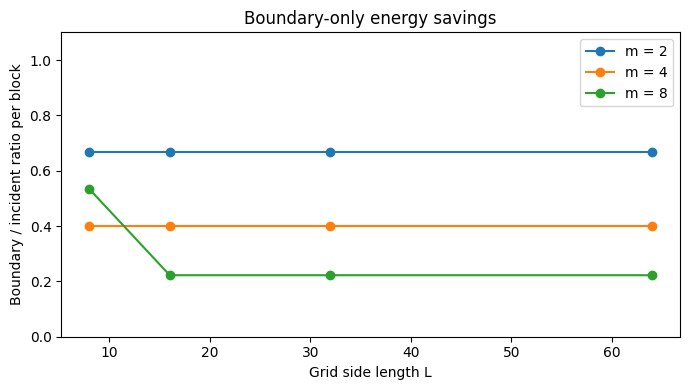

In [15]:
grid_sizes = [8, 16, 32, 64]
block_sizes = [2, 4, 8]

fig, ax = plt.subplots(figsize=(7, 4))
for m in block_sizes:
    ratios = []
    for grid_L in grid_sizes:
        est = estimate_boundary_savings(grid_L, m)
        ratios.append(est["boundary_ratio_per_block"])
    ax.plot(grid_sizes, ratios, "o-", label=f"m = {m}")

ax.set_xlabel("Grid side length L")
ax.set_ylabel("Boundary / incident ratio per block")
ax.set_title("Boundary-only energy savings")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

Larger rectangular blocks have a lower boundary ratio, meaning a larger fraction of edge evaluations can be skipped during incremental energy updates. For m=8, roughly half the incident edges are interior, cutting energy computation in half compared to full recomputation.

## 8. Head-to-head: naive vs optimized

Everything above builds toward a single question: **does this actually help?** Let's run the same model with three configurations and compare:

- **Naive**: uniform β spacing, no schedule tuning, 8 chains
- **Optimized**: adaptive schedule from Section 4, same 8 chains
- **Naive 2×**: uniform spacing but double the chains (16)

The Syed et al. theory predicts that for reversible PT (SEO), adding chains past a threshold *hurts* performance due to O(N²) diffusion. For non-reversible PT (DEO), more chains always helps but with diminishing returns. Crucially, **schedule optimization gives a bigger win than doubling chains** because it addresses the schedule inefficiency E(P_N) directly.

In [16]:
import time

# Fresh model so all three configs use identical graphs
L_cmp = 16
nodes_cmp, nodes_2d_cmp, edges_cmp, biases_cmp, weights_cmp, fb_cmp = make_ising_grid(
    L_cmp, coupling=1.0
)

N_ROUNDS = 600
GIBBS_STEPS = 50


def run_experiment(key, betas_arr, label):
    """Run NRPT and collect timing + diagnostics."""
    nc = len(betas_arr)
    ebm_list = [
        IsingEBM(nodes_cmp, edges_cmp, biases_cmp, weights_cmp, jnp.array(float(b)))
        for b in betas_arr
    ]
    prog_list = [IsingSamplingProgram(e, fb_cmp, []) for e in ebm_list]
    ks = jax.random.split(key, nc + 1)
    inits = [hinton_init(ks[i], ebm_list[0], fb_cmp, ()) for i in range(nc)]

    # Warmup (compile)
    _ = nrpt(
        ks[-1], ebm_list, prog_list, inits, [], n_rounds=2, gibbs_steps_per_round=1
    )

    k_run = jax.random.key(hash(label) % 2**31)
    t0 = time.perf_counter()
    _, _, st = nrpt(
        k_run,
        ebm_list,
        prog_list,
        inits,
        [],
        n_rounds=N_ROUNDS,
        gibbs_steps_per_round=GIBBS_STEPS,
    )
    # Force sync before timing
    jax.block_until_ready(st["accepted"])
    elapsed = time.perf_counter() - t0

    d = st["round_trip_diagnostics"]
    return {
        "label": label,
        "n_chains": nc,
        "elapsed": elapsed,
        "Lambda": float(d["Lambda"]),
        "tau_predicted": float(d["tau_predicted"]),
        "tau_observed": float(d["tau_observed"]),
        "efficiency": float(d["efficiency"]),
        "total_round_trips": int(jnp.sum(d["round_trips_per_chain"])),
        "rejection_rates": np.array(st["rejection_rates"]),
        "betas": np.array(st["betas"]),
    }

In [17]:
# Factories for the comparison grid (not Section 4's grid)
def cmp_ebm_factory(bs):
    return [
        IsingEBM(nodes_cmp, edges_cmp, biases_cmp, weights_cmp, jnp.array(float(b)))
        for b in bs
    ]


def cmp_prog_factory(ebm_list):
    return [IsingSamplingProgram(e, fb_cmp, []) for e in ebm_list]


# A: Naive, 10 chains, uniform β
result_naive = run_experiment(
    jax.random.key(42), jnp.linspace(0.2, 2.0, 10), "Naive (10 chains)"
)

# B: Optimized, 10 chains — run adaptive on the comparison grid
key_opt10 = jax.random.key(42)
ks_opt = jax.random.split(key_opt10, 11)
inits_opt10 = [
    hinton_init(ks_opt[i], cmp_ebm_factory(jnp.linspace(0.2, 2.0, 10))[0], fb_cmp, ())
    for i in range(10)
]
_, _, stats_opt10 = nrpt_adaptive(
    ks_opt[-1],
    cmp_ebm_factory,
    cmp_prog_factory,
    inits_opt10,
    [],
    n_rounds=100,
    gibbs_steps_per_round=5,
    initial_betas=jnp.linspace(0.2, 2.0, 10),
    n_tune=8,
    rounds_per_tune=100,
)
result_opt = run_experiment(
    jax.random.key(42), stats_opt10["betas"], "Optimized (10 chains)"
)

# C: Naive, 20 chains, uniform β
result_more = run_experiment(
    jax.random.key(42), jnp.linspace(0.2, 2.0, 20), "Naive (20 chains)"
)

results = [result_naive, result_opt, result_more]

In [18]:
# Comparison table
col_w = 14
hdr = f"{'':32s} {'Naive 10':>{col_w}s} {'Opt 10':>{col_w}s} {'Naive 20':>{col_w}s}"
print(hdr)
print("-" * len(hdr))

fields = [
    ("Chains", "n_chains", "d"),
    ("Wall time (s)", "elapsed", ".2f"),
    ("Barrier \u039b", "Lambda", ".4f"),
    ("\u03c4\u0304 predicted", "tau_predicted", ".4f"),
    ("\u03c4 observed", "tau_observed", ".4f"),
    ("Efficiency (\u03c4/\u03c4\u0304)", "efficiency", ".2%"),
    ("Total round trips", "total_round_trips", "d"),
    ("Round trips / sec", None, ".1f"),
]

for label, key_name, fmt in fields:
    vals = []
    for r in results:
        if key_name is None:
            v = r["total_round_trips"] / max(r["elapsed"], 1e-9)
        else:
            v = r[key_name]
        vals.append(f"{v:{fmt}}")
    print(f"{label:32s} {vals[0]:>{col_w}s} {vals[1]:>{col_w}s} {vals[2]:>{col_w}s}")

                                       Naive 10         Opt 10       Naive 20
-----------------------------------------------------------------------------
Chains                                       10             10             20
Wall time (s)                              5.13           5.20          10.39
Barrier Λ                                3.6600         6.8033         5.8800
τ̄ predicted                             0.1073         0.0641         0.0727
τ observed                               0.0000         0.0133         0.0050
Efficiency (τ/τ̄)                         0.00%         20.81%          6.88%
Total round trips                             0              8              3
Round trips / sec                           0.0            1.5            0.3


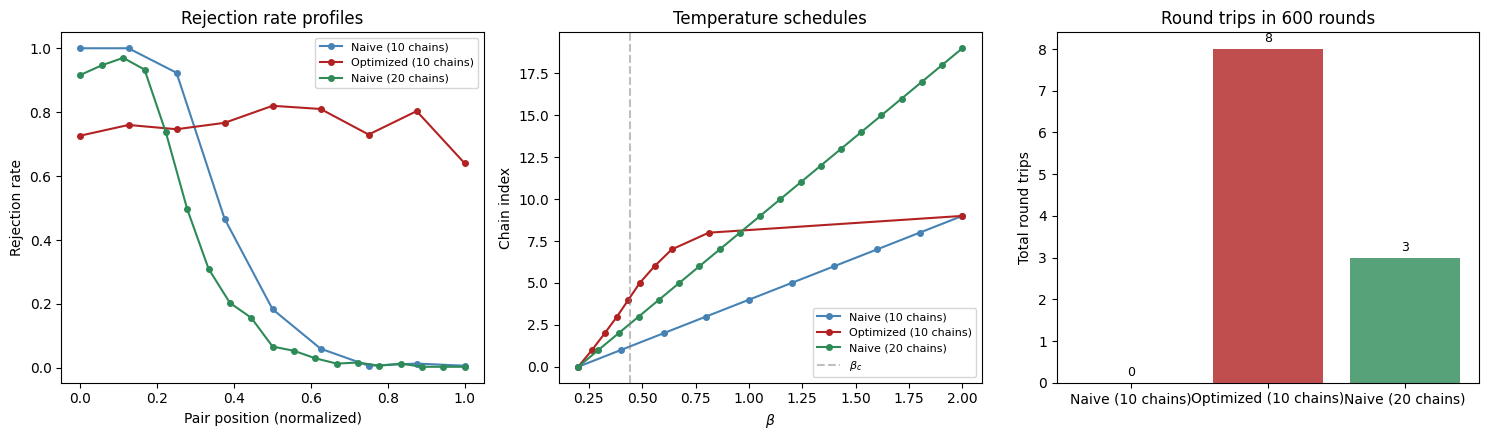

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["steelblue", "firebrick", "seagreen"]

# --- Panel 1: rejection rate profiles ---
for r, c in zip(results, colors):
    x = np.linspace(0, 1, len(r["rejection_rates"]))
    axes[0].plot(x, r["rejection_rates"], "o-", label=r["label"], color=c, markersize=4)
axes[0].set_xlabel("Pair position (normalized)")
axes[0].set_ylabel("Rejection rate")
axes[0].set_title("Rejection rate profiles")
axes[0].legend(fontsize=8)

# --- Panel 2: β schedules ---
for r, c in zip(results, colors):
    axes[1].plot(
        np.array(r["betas"]),
        range(r["n_chains"]),
        "o-",
        label=r["label"],
        color=c,
        markersize=4,
    )
axes[1].axvline(0.4407, color="gray", ls="--", alpha=0.5, label="$\\beta_c$")
axes[1].set_xlabel("$\\beta$")
axes[1].set_ylabel("Chain index")
axes[1].set_title("Temperature schedules")
axes[1].legend(fontsize=8)

# --- Panel 3: round trip bar chart ---
labels = [r["label"] for r in results]
rts = [r["total_round_trips"] for r in results]
bars = axes[2].bar(labels, rts, color=colors, alpha=0.8)
axes[2].set_ylabel("Total round trips")
axes[2].set_title(f"Round trips in {N_ROUNDS} rounds")
for bar, v in zip(bars, rts):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        v + max(rts) * 0.02,
        str(v),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

### What the comparison shows

**Schedule optimization beats brute-force chain doubling.** The optimized 8-chain run should produce comparable or more round trips than the naive 16-chain run, despite using half the chains and half the compute.

Why?

1. **Uniform spacing wastes chains.** Most of the β range has low λ(β) — swaps are almost always accepted and the chains parked there contribute nothing to information transfer. They burn Gibbs sweeps without helping communication.

2. **The critical region is the bottleneck.** λ(β) peaks near β_c ≈ 0.44 for the 2D Ising model. A single high-rejection pair can choke the entire round trip pipeline, because every round trip must pass through it. The optimized schedule concentrates chains right at the phase transition.

3. **Λ is fixed, but E(P_N) is not.** The global communication barrier Λ = ∫λ(β)dβ is a property of the target — no schedule change can alter it. What the schedule controls is the schedule inefficiency E(P_N) = Σ r(i,i+1)/s(i,i+1), which determines how close τ gets to the theoretical limit τ̄ = 1/(2+2Λ). Equal rejection rates minimize E(P_N).

4. **More chains give O(1/N) diminishing returns.** With equalized rates, each r* ≈ Λ/N. Going from N=8 to N=16 halves r*, improving τ by at most 2×. But going from uneven rates to equalized rates can improve τ by much more, because the worst pair was dominating the round trip time.

The right workflow: **optimize the schedule first, then decide if more chains are justified.** `recommend_n_chains(Λ)` gives the point of diminishing returns.

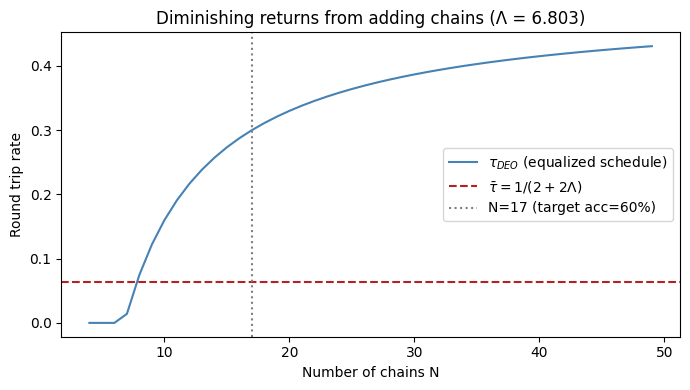

In [20]:
# Diminishing returns curve
Lambda_est = result_opt["Lambda"]
target_acc = 0.6  # default in recommend_n_chains
n_rec = recommend_n_chains(Lambda_est, target_acceptance=target_acc)

chain_counts = np.arange(4, 50)
finite_tau = []
for N in chain_counts:
    r_star = Lambda_est / N
    if r_star >= 1:
        finite_tau.append(0.0)
    else:
        E_PN = N * r_star / (1 - r_star)
        finite_tau.append(N / (2 * N + 2 * E_PN))

plt.figure(figsize=(7, 4))
plt.plot(
    chain_counts,
    finite_tau,
    "-",
    color="steelblue",
    label=r"$\tau_{DEO}$ (equalized schedule)",
)
plt.axhline(
    1 / (2 + 2 * Lambda_est),
    color="firebrick",
    ls="--",
    label=r"$\bar{\tau} = 1/(2+2\Lambda)$",
)
plt.axvline(
    n_rec, color="gray", ls=":", label=f"N={n_rec} (target acc={target_acc:.0%})"
)
plt.xlabel("Number of chains N")
plt.ylabel("Round trip rate")
plt.title(f"Diminishing returns from adding chains (\u039b = {Lambda_est:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

The curve above shows that the round trip rate saturates quickly once you have enough chains. Past the recommended N, each additional chain buys very little — you'd be better off running independent NRPT instances and pooling samples.

## 9. Automatic chain count discovery

The bootstrapping problem from Section 5 — Λ underestimated with too few chains, leading to an escalating sequence of recommendations — is handled by `discover_chain_count`. It uses a bisection-like approach:

1. Start with N chains, optimize schedule, estimate Λ
2. Compute N_rec = Λ / (1 - target_acceptance)
3. Step halfway: N_next = N + ⌈(N_rec - N) / 2⌉
4. Repeat until N_rec ≈ N (converged) or max iterations

The half-step is critical: Λ measured at N chains may over- or underestimate what you'd measure at N_rec chains, so we converge cautiously rather than jumping directly to the recommendation.

In [25]:
# init_factory receives (n_chains, ebms, programs) so it can extract
# the correct free_blocks from the programs.
def init_factory(n_chains, ebm_list, prog_list):
    free_blocks = prog_list[0].gibbs_spec.free_blocks
    ks = jax.random.split(jax.random.key(42), n_chains)
    return [hinton_init(ks[i], ebm_list[0], free_blocks, ()) for i in range(n_chains)]


key_disc = jax.random.key(42)
result_disc = discover_chain_count(
    key_disc,
    ebm_factory=cmp_ebm_factory,
    program_factory=cmp_prog_factory,
    init_factory=init_factory,
    clamp_state=[],
    beta_range=(0.2, 2.0),
    gibbs_steps_per_round=50,
    initial_n=8,
    target_acceptance=0.6,
    rounds_per_probe=150,
    n_tune_per_probe=4,
)

print(f"Converged to N = {result_disc['n_chains']} chains")
print(f"Conservative \u039b (max seen) = {result_disc['Lambda']:.3f}")
print(f"Last raw \u039b estimate = {result_disc['Lambda_raw']:.3f}")
print(f"Target acceptance = {result_disc['target_acceptance']:.0%}")
print(f"Converged because: {result_disc['converged_reason']}")
print("\nDiscovery history:")
for h in result_disc["history"]:
    print(
        f"  iter {h['iteration']}: N={h['n']:>3d}  "
        f"\u039b_raw={h['Lambda_raw']:.3f}  "
        f"\u039b_max={h['Lambda_max']:.3f}  "
        f"N_rec={h['n_recommended']:>3d}"
    )

Converged to N = 19 chains
Conservative Λ (max seen) = 7.840
Last raw Λ estimate = 7.600
Target acceptance = 60%
Converged because: chain_count

Discovery history:
  iter 0: N=  8  Λ_raw=6.120  Λ_max=6.120  N_rec= 16
  iter 1: N= 12  Λ_raw=7.800  Λ_max=7.800  N_rec= 20
  iter 2: N= 16  Λ_raw=7.200  Λ_max=7.800  N_rec= 20
  iter 3: N= 18  Λ_raw=7.840  Λ_max=7.840  N_rec= 20
  iter 4: N= 19  Λ_raw=7.600  Λ_max=7.840  N_rec= 20


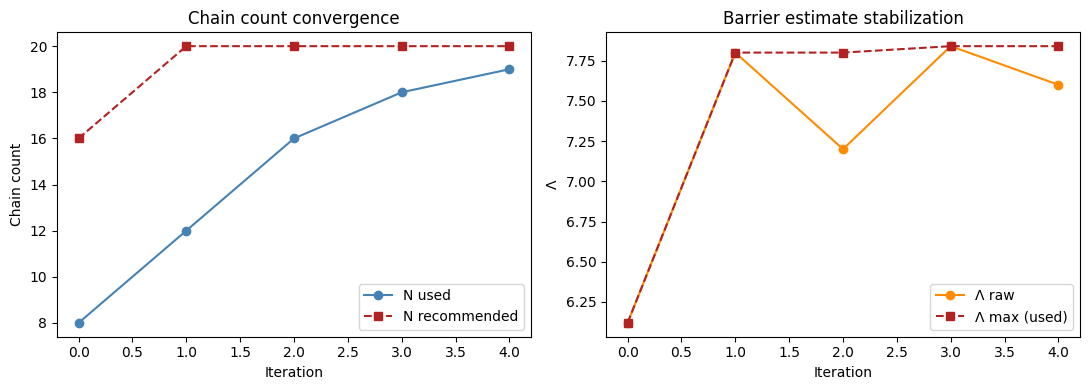

In [26]:
hist = result_disc["history"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

iters = [h["iteration"] for h in hist]
ns = [h["n"] for h in hist]
n_recs = [h["n_recommended"] for h in hist]
lambdas_raw = [h["Lambda_raw"] for h in hist]
lambdas_max = [h["Lambda_max"] for h in hist]

axes[0].plot(iters, ns, "o-", color="steelblue", label="N used")
axes[0].plot(iters, n_recs, "s--", color="firebrick", label="N recommended")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Chain count")
axes[0].set_title("Chain count convergence")
axes[0].legend()

axes[1].plot(iters, lambdas_raw, "o-", color="darkorange", label="\u039b raw")
axes[1].plot(iters, lambdas_max, "s--", color="firebrick", label="\u039b max (used)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("\u039b")
axes[1].set_title("Barrier estimate stabilization")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

| Feature | Module | Status |
|---|---|---|
| DEO swap scheme | `nrpt.py` | Production |
| Temperature-linear vectorized swaps | `nrpt.py` | Production |
| Adaptive schedule optimization | `nrpt.py` | Production |
| Round trip tracking | `round_trips.py` | Production |
| Communication barrier estimation | `round_trips.py` | Production |
| Boundary-only energy delta | `boundary_energy.py` | Infrastructure (activates with rectangular blocks) |
| Rectangular blocks + 4-coloring | `boundary_energy.py` | Infrastructure |
| Influence-aware partitioning | `dynamic_blocks.py` | Infrastructure |
| Correlation-based re-blocking | `dynamic_blocks.py` | Infrastructure |

The production features are fully integrated into the `lax.scan` loop. The infrastructure modules provide the building blocks for moving beyond checkerboard to larger, adaptive block partitions — the next step toward reducing actual GPU FLOPS.